In [1]:
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root

In [4]:
def Hill_Func(p, theta, n):
    f = p**n/(p**n+theta**n)
    return f

def complete_model_1(z, t):
    ra = z[0]
    rb = z[1]
    pa = z[2]
    pb = z[3]

    ma = 2.35
    mb = 2.35
    na = 3.0
    nb = 3.0
    gamma_a = 1.0
    gamma_b = 1.0
    theta_a = 0.21
    theta_b = 0.21 
    delta_pa = 1.0
    delta_pb = 1.0
    k_pa = 1.0
    k_pb = 1.0

    dradt = ma * Hill_Func(pb, theta_b, nb) - gamma_a * ra
    drbdt = mb - gamma_b * rb
    dpadt = k_pa * ra - delta_pa * pa
    dpbdt = k_pb * rb - delta_pb * pb

    return [dradt, drbdt, dpadt, dpbdt]

def complete_model_2(x, t):
    ua = x[0]
    ub = x[1]
    sa = x[2]
    sb = x[3]
    pa = x[4]
    pb = x[5]

    ma = 2.35
    mb = 2.35
    na = 3.0
    nb = 3.0
    beta_a = 2.35
    beta_b = 2.35
    gamma_a = 1.0
    gamma_b = 1.0
    theta_a = 0.21
    theta_b = 0.21 
    delta_pa = 1.0
    delta_pb = 1.0
    k_pa = 1.0
    k_pb = 1.0

    duadt = ma * Hill_Func(pb, theta_b, nb) - beta_a * ua
    dubdt = mb - beta_b * (1 - Hill_Func(pa, theta_a, na)) * ub
    dsadt = beta_a * ua - gamma_a * sa
    dsbdt = beta_b * (1 - Hill_Func(pa, theta_a, na)) * ub - gamma_b * sb
    dpadt = k_pa * sa - delta_pa * pa
    dpbdt = k_pb * sb - delta_pb * pb

    return [duadt, dubdt, dsadt, dsbdt, dpadt, dpbdt]


## Mechanism 1

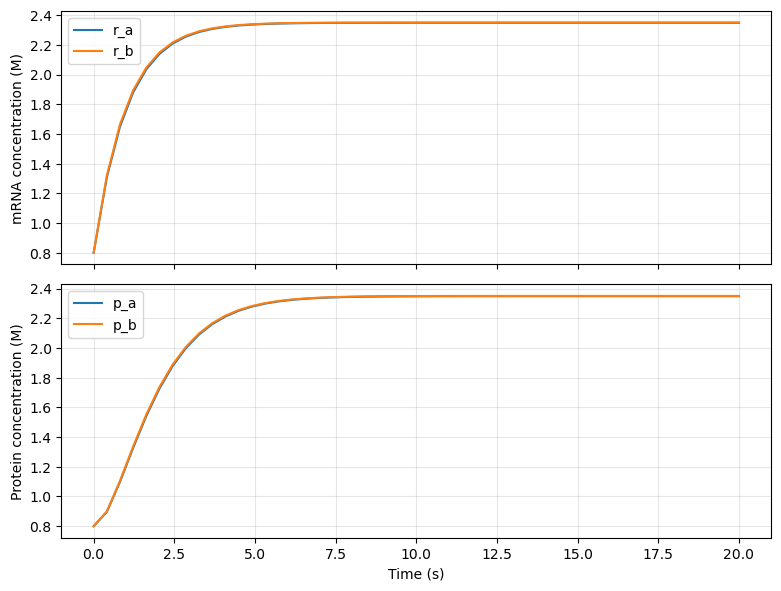

In [5]:
# initial conditions
z0 = [0.8,0.8,0.8,0.8]
# time points
t = np.linspace(0,20)

# solve ODE
sol_1 = odeint(complete_model_1,z0,t)

fig, ax = plt.subplots(2, 1, figsize=(8,6), sharex=True)

ax[0].plot(t, sol_1[:, 0], label='r_a')
ax[0].plot(t, sol_1[:, 1], label='r_b')
ax[0].set_ylabel('mRNA concentration (M)')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].plot(t, sol_1[:, 2], label='p_a')
ax[1].plot(t, sol_1[:, 3], label='p_b')
ax[1].set_ylabel('Protein concentration (M)')
ax[1].set_xlabel('Time (s)')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [6]:
# find fixed point
def f(z):
    return np.array(complete_model_1(z, 0.0))

def jacobian_fd(f, z, eps=1e-6):
    z = np.asarray(z, float)
    f0 = f(z)
    J = np.zeros((len(z), len(z)))
    for j in range(len(z)):
        zp = z.copy()
        zp[j] += eps
        J[:, j] = (f(zp) - f0) / eps
    return J


z0 = np.array([0.8,0.8,0.8,0.8], float)
fixed = root(f, z0)
J = jacobian_fd(f, fixed.x)
eig = np.linalg.eigvals(J)

print(fixed.success, fixed.message)
print("fixed point:", fixed.x)
print("residual ||f(z*)||:", np.linalg.norm(f(fixed.x)))
print("Eigenvalues:", eig)
print("Stable?" , np.all(np.real(eig) < 0))

True The solution converged.
fixed point: [2.34832424 2.35       2.34832424 2.35      ]
residual ||f(z*)||: 0.0
Eigenvalues: [-1. -1. -1. -1.]
Stable? True


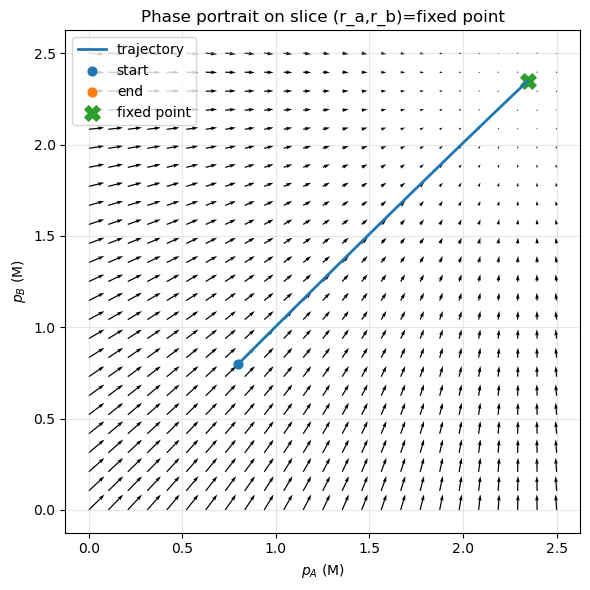

In [8]:
def rhs(z):
    return np.array(complete_model_1(z, 0.0))  # t not used

# grid in (p_a, p_b)
pa = np.linspace(0, 2.5, 25)
pb = np.linspace(0, 2.5, 25)
PA, PB = np.meshgrid(pa, pb)

# freeze r_a, r_b
z_fp = fixed.x
ra0, rb0 = z_fp[0], z_fp[1]

U = np.zeros_like(PA)  # d(p_a)/dt
V = np.zeros_like(PB)  # d(p_b)/dt

for i in range(PA.shape[0]):
    for j in range(PA.shape[1]):
        z = [ra0, rb0, PA[i, j], PB[i, j]]
        dz = rhs(z)
        U[i, j] = dz[2]
        V[i, j] = dz[3]

# solve trajectory (same as before)
z0 = [0.8, 0.8, 0.8, 0.8]
t = np.linspace(0, 50, 2000)
sol_1 = odeint(complete_model_1, z0, t)

z_fp = fixed.x

plt.figure(figsize=(6,6))
plt.quiver(PA, PB, U, V, angles='xy')
plt.plot(sol_1[:, 2], sol_1[:, 3], lw=2, label='trajectory')
plt.scatter(sol_1[0, 2], sol_1[0, 3], s=40, label='start')
plt.scatter(sol_1[-1, 2], sol_1[-1, 3], s=40, label='end')
# plot fixed point in this projection
plt.scatter(z_fp[2], z_fp[3], s=120, marker="X", label="fixed point")

plt.xlabel(r'$p_A$ (M)')
plt.ylabel(r'$p_B$ (M)')
plt.title('Phase portrait on slice (r_a,r_b)=fixed point')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Mechanism 2

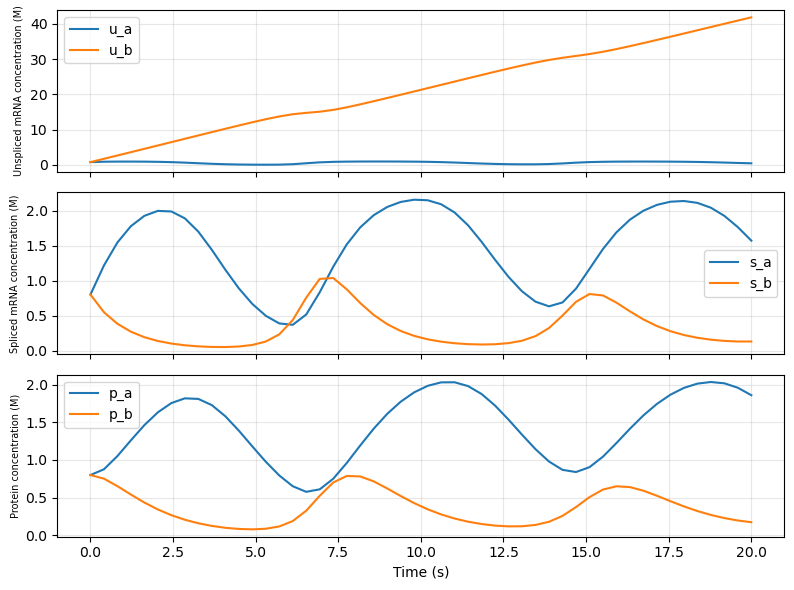

In [9]:
# initial conditions
x0 = [0.8,0.8,0.8,0.8,0.8,0.8]
# time points
t = np.linspace(0,20)

# solve ODE
sol_2 = odeint(complete_model_2,x0,t)

fig, ax = plt.subplots(3, 1, figsize=(8,6), sharex=True)

ax[0].plot(t, sol_2[:, 0], label='u_a')
ax[0].plot(t, sol_2[:, 1], label='u_b')
ax[0].set_ylabel('Unspliced mRNA concentration (M)',fontsize = 7)
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].plot(t, sol_2[:, 2], label='s_a')
ax[1].plot(t, sol_2[:, 3], label='s_b')
ax[1].set_ylabel('Spliced mRNA concentration (M)',fontsize = 7)
ax[1].legend()
ax[1].grid(True, alpha=0.3)

ax[2].plot(t, sol_2[:, 4], label='p_a')
ax[2].plot(t, sol_2[:, 5], label='p_b')
ax[2].set_ylabel('Protein concentration (M)',fontsize = 7)
ax[2].set_xlabel('Time (s)')
ax[2].legend()
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
# fixed point residual function (Mechanism 2)
def f2(z):
    return np.array(complete_model_2(z, 0.0), dtype=float)

# initial guess must be 6D now
x0 = np.array([0.8, 0.8, 0.8, 0.8, 0.8, 0.8], float)

fixed = root(f2, x0, method="hybr") 

print(fixed.success, fixed.message)
print("fixed point:", fixed.x)
print("residual ||f(z*)||:", np.linalg.norm(f2(fixed.x)))

if fixed.success:
    J = jacobian_fd(f2, fixed.x)
    eig = np.linalg.eigvals(J)
    print("Eigenvalues:", eig)
    print("Stable?", np.all(np.real(eig) < 0))

True The solution converged.
fixed point: [9.99286910e-01 1.39935132e+03 2.34832424e+00 2.35000000e+00
 2.34832424e+00 2.35000000e+00]
residual ||f(z*)||: 4.1073618719167554e-13
Eigenvalues: [-2.35448087e+00+0.j         -1.22568437e+00+0.25201196j
 -1.22568437e+00-0.25201196j -7.72080583e-01+0.21316811j
 -7.72080583e-01-0.21316811j -1.66856928e-03+0.j        ]
Stable? True


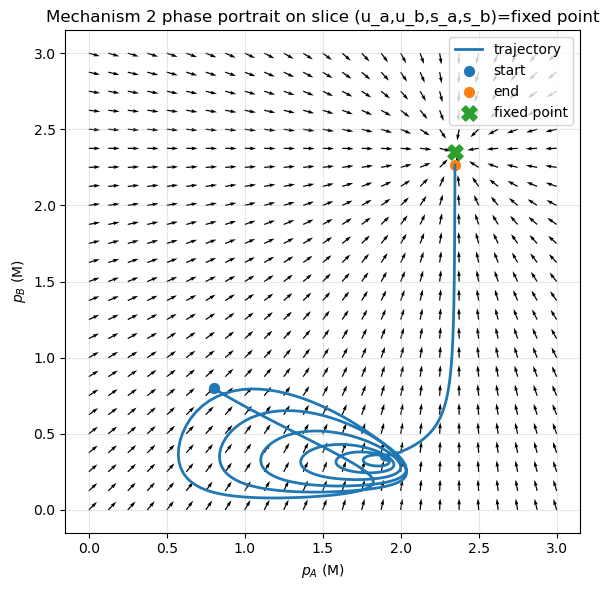

In [29]:
# Mechanism 2 RHS
def rhs2(z):
    return np.array(complete_model_2(z, 0.0), dtype=float)  

# grid in (p_a, p_b)
pa = np.linspace(0, 3.0, 25)
pb = np.linspace(0, 3.0, 25)
PA, PB = np.meshgrid(pa, pb)

# fixed point
z_fp = fixed.x

# freeze (u_a, u_b, s_a, s_b) at the fixed point
ua0, ub0, sa0, sb0 = z_fp[0], z_fp[1], z_fp[2], z_fp[3]

U = np.zeros_like(PA)  # d(p_a)/dt
V = np.zeros_like(PB)  # d(p_b)/dt

for i in range(PA.shape[0]):
    for j in range(PA.shape[1]):
        z = [ua0, ub0, sa0, sb0, PA[i, j], PB[i, j]]
        dz = rhs2(z)
        U[i, j] = dz[4]   # dp_a/dt
        V[i, j] = dz[5]   # dp_b/dt

speed = np.sqrt(U**2 + V**2) + 1e-12
Un = U / speed
Vn = V / speed

# simulate trajectory 
z0 = [0.8, 0.8, 0.8, 0.8, 0.8, 0.8]
t = np.linspace(0, 2000, 20000)   
sol_2 = odeint(complete_model_2, z0, t)

plt.figure(figsize=(6,6))
plt.quiver(PA, PB, Un, Vn, angles='xy') 

plt.plot(sol_2[:, 4], sol_2[:, 5], lw=2, label='trajectory')  # (p_a, p_b)
plt.scatter(sol_2[0, 4], sol_2[0, 5], s=50, label='start')
plt.scatter(sol_2[-1, 4], sol_2[-1, 5], s=50, label='end')

# fixed point on this projection
plt.scatter(z_fp[4], z_fp[5], s=120, marker="X", label="fixed point")

plt.xlabel(r'$p_A$ (M)')
plt.ylabel(r'$p_B$ (M)')
plt.title('Mechanism 2 phase portrait on slice (u_a,u_b,s_a,s_b)=fixed point')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()